In [ ]:
# --- CELLULE 1 : Imports ---
import cv2
import numpy as np
import os
import shutil
import zipfile
from google.colab import files
import matplotlib.pyplot as plt

In [ ]:
# --- CELLULE 2 : Upload des images ---
INPUT_DIR = "input_images"
OUTPUT_DIR = "output_images"

os.makedirs(INPUT_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Sélectionnez vos images (plusieurs à la fois, ou un .zip contenant tout) :")
uploaded = files.upload()

for filename in uploaded.keys():
    if filename.lower().endswith(".zip"):
        with zipfile.ZipFile(filename, "r") as z:
            z.extractall(INPUT_DIR)
        os.remove(filename)
    else:
        shutil.move(filename, os.path.join(INPUT_DIR, filename))

# Aplatit les éventuels sous-dossiers issus du zip
for root, dirs, filenames in os.walk(INPUT_DIR):
    for f in filenames:
        src = os.path.join(root, f)
        dst = os.path.join(INPUT_DIR, f)
        if src != dst:
            shutil.move(src, dst)

image_files = [
    f for f in os.listdir(INPUT_DIR)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"))
]
print(f"\n{len(image_files)} images détectées.")

Sélectionnez vos images (plusieurs à la fois, ou un .zip contenant tout) :


Saving 1054_description_c_thresh.png to 1054_description_c_thresh.png
Saving 1054_description_D_thresh.png to 1054_description_D_thresh.png
Saving 1054_description_e_thresh.png to 1054_description_e_thresh.png
Saving 1054_description_i_thresh.png to 1054_description_i_thresh.png
Saving 1054_description_i2_thresh.png to 1054_description_i2_thresh.png
Saving 1054_description_n_thresh.png to 1054_description_n_thresh.png
Saving 1054_description_o_thresh.png to 1054_description_o_thresh.png
Saving 1054_description_p_thresh.png to 1054_description_p_thresh.png
Saving 1054_description_r_thresh.png to 1054_description_r_thresh.png
Saving 1054_description_s_thresh.png to 1054_description_s_thresh.png
Saving 1054_description_t_thresh.png to 1054_description_t_thresh.png
Saving 1054_Frankendal_a_thresh.png to 1054_Frankendal_a_thresh.png
Saving 1054_Frankendal_a2_thresh.png to 1054_Frankendal_a2_thresh.png
Saving 1054_Frankendal_d_thresh.png to 1054_Frankendal_d_thresh.png
Saving 1054_Frankendal

In [ ]:
# --- CELLULE 3 : Réglages ---
TARGET_SIZE = 32          # taille finale (carré TARGET_SIZE x TARGET_SIZE)
PAD_COLOR = 255              # couleur du padding : 0 = noir, 255 = blanc (image en niveaux de gris)
                           # pour une image couleur, utilisez un tuple (B, G, R), ex: (255, 255, 255)
INTERPOLATION = cv2.INTER_AREA  # bonne interpolation pour réduire la taille

def pad_to_square(img, color):
    h, w = img.shape[:2]
    size = max(h, w)

    # Calcul du padding à ajouter de chaque côté pour centrer l'image
    top = (size - h) // 2
    bottom = size - h - top
    left = (size - w) // 2
    right = size - w - left

    if img.ndim == 2:  # image en niveaux de gris
        border_value = color if isinstance(color, int) else color[0]
    else:
        border_value = color if isinstance(color, tuple) else (color, color, color)

    padded = cv2.copyMakeBorder(
        img, top, bottom, left, right,
        borderType=cv2.BORDER_CONSTANT,
        value=border_value
    )
    return padded

def process_image(img):
    squared = pad_to_square(img, PAD_COLOR)
    resized = cv2.resize(squared, (TARGET_SIZE, TARGET_SIZE), interpolation=INTERPOLATION)
    return resized

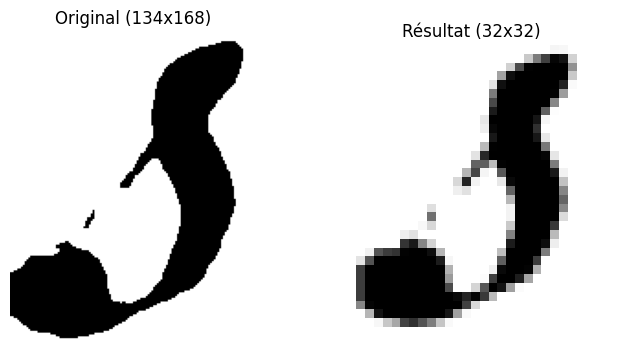

Si le résultat vous convient, passez à la cellule suivante. Sinon, ajustez TARGET_SIZE / PAD_COLOR ci-dessus et relancez cette cellule.


In [ ]:
# --- CELLULE 4 : Aperçu sur une image avant de tout lancer ---
if image_files:
    sample_path = os.path.join(INPUT_DIR, image_files[0])
    sample_img = cv2.imread(sample_path, cv2.IMREAD_UNCHANGED)
    sample_result = process_image(sample_img)

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))

    def show(ax, image, title):
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
        ax.set_title(title)
        ax.axis("off")

    show(axes[0], sample_img, f"Original ({sample_img.shape[1]}x{sample_img.shape[0]})")
    show(axes[1], sample_result, f"Résultat ({TARGET_SIZE}x{TARGET_SIZE})")
    plt.show()

    print("Si le résultat vous convient, passez à la cellule suivante. "
          "Sinon, ajustez TARGET_SIZE / PAD_COLOR ci-dessus et relancez cette cellule.")


In [ ]:
# --- CELLULE 5 : Traitement de toutes les images ---
processed_count = 0
errors = []

for fname in image_files:
    try:
        path = os.path.join(INPUT_DIR, fname)
        img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
        if img is None:
            errors.append(fname)
            continue
        result = process_image(img)

        out_name = os.path.splitext(fname)[0] + "_32x32.png"
        cv2.imwrite(os.path.join(OUTPUT_DIR, out_name), result)
        processed_count += 1
    except Exception as e:
        errors.append(f"{fname} ({e})")

print(f"\n{processed_count} images traitées avec succès.")
if errors:
    print(f"{len(errors)} erreurs : {errors}")


128 images traitées avec succès.


In [ ]:
# --- CELLULE 6 : Zipper et télécharger le résultat ---
zip_name = "images_32x32.zip"
shutil.make_archive("images_32x32", "zip", OUTPUT_DIR)
files.download(zip_name)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>